### Business Problem: Optimizing Loan Portfolio Profitability While Minimizing Risk Exposure
Background:
A financial institution wants to grow its loan portfolio by approving more applications without significantly increasing its default risk. Historically, overly cautious approval strategies have led to lost revenue opportunities, while lenient strategies have increased default rates and write-offs.

#### Objective:
Use predictive modeling to identify applicants who are both **likely to repay their loans and profitable to approve**, balancing approval rates with financial risk and expected returns.

#### Key Questions to Address:
##### I] Risk Assessment (Regression Task)

1) What is the predicted RiskScore for a new applicant, indicating the likelihood of default?

2) How does this score correlate with key variables like credit history, debt-to-income ratio, or loan purpose?

##### II] Loan Approval (Classification Task)

1) Should this applicant be approved or denied for a loan based on their financial profile?

##### Strategic Decisioning

1) How can we segment applicants (e.g., low-risk/high-value, high-risk/low-value) to refine lending strategies?

2) What threshold on the RiskScore corresponds to optimal approval criteria (balancing profit vs. risk)?

3) Can we dynamically adjust interest rates based on predicted risk and expected loss?

### Task 2: Loan Approval Prediction

#### Understanding the dataset

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the dataset
df = pd.read_csv("Loan.csv")

In [4]:
df.head(2)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
# df[['TotalDebtToIncomeRatio', 'DebtToIncomeRatio','MonthlyDebtPayments', 'MonthlyIncome', 'AnnualIncome']].head()
# df[['LoanAmount', 'LoanDuration','BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'MonthlyIncome', 'Monthly_LoanToIncomeRatio']].head()

##### Calculated Metrics
-----------------
P = Loan Amount

r = Interest Rate (NOT Base Interest Rate)

n = Loan Duration in Months

**Monthly Loan Amount** = P * r * (1 + r)^n / ((1 + r)^n - 1)

-----------------

**Net worth** = Total Assets - Total Liabilities

-----------------

**AnnualIncome** = MonthlyIncome * 12

-----------------

**DebtToIncomeRatio** = MonthlyDebtPayment / MonthlyIncome

-----------------

**InterestRate** = BaseInterestRate + Margin

-----------------

**Monthly_LoanToIncomeRatio** = MonthlyLoanAmount / MonthlyIncome



In [ ]:
# Getting a preview of the dataset
# df[df['LoanApproved']==0][['RiskScore']].describe()

In [57]:
df['HomeOwnershipStatus'].unique()

array(['Own', 'Mortgage', 'Rent', 'Other'], dtype=object)

In [3]:
print("Original Shape of Dataset")
df.shape

Original Shape of Dataset


(20000, 36)

In [3]:
# Dropping column to correctly calculate the metric
df.drop(columns=['DebtToIncomeRatio'], axis=1, inplace=True)

In [4]:
# Calculate Debt to Income Ratio (using monthly income and debt amounts)
df['DebtToIncomeRatio'] = df['MonthlyDebtPayments']/df['MonthlyIncome']
df['Monthly_LoanToIncomeRatio'] = df['MonthlyLoanPayment']/df['MonthlyIncome']

In [5]:
# Dropping unnecessary columns
df.drop(columns=[
    'TotalDebtToIncomeRatio',
    'AnnualIncome', 
    'LoanAmount',
    'LoanDuration',
    'MonthlyDebtPayments',
    'MonthlyIncome',
    'BaseInterestRate',
    'InterestRate',
    'MonthlyLoanPayment',
    'TotalAssets',
    'TotalLiabilities'
    ], axis=1, inplace=True)

In [ ]:
print("Shape of Dataset after removing Unnecessary Columns")
df.shape

Shape of Dataset after removing Unnecessary Columns


(20000, 26)

##### Cleaning Application Date Column

In [6]:
# Converting the date column to datetime
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

# Extracting Year and Month from Application Date (this will be useful to perform trend analysis)
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month

In [14]:
df[['ApplicationDate', 'ApplicationYear', 'ApplicationMonth']].head(2)

,ApplicationDate,ApplicationYear,ApplicationMonth
0,2018-01-01,2018,1
1,2018-01-02,2018,1


In [7]:
# Revising the Application date column
# df = df[~df['ApplicationYear'].isin([2067, 2068, 2069, 2070, 2071, 2072])]

conditions = [
    ((df['ApplicationYear'] >= 2025) & (df['ApplicationYear'] <= 2031)) | (df['ApplicationYear'] == 2018),
    ((df['ApplicationYear'] >= 2032) & (df['ApplicationYear'] <= 2038)) | (df['ApplicationYear'] == 2019),
    ((df['ApplicationYear'] >= 2039) & (df['ApplicationYear'] <= 2045)) | (df['ApplicationYear'] == 2020),
    ((df['ApplicationYear'] >= 2046) & (df['ApplicationYear'] <= 2052)) | (df['ApplicationYear'] == 2021),
    ((df['ApplicationYear'] >= 2053) & (df['ApplicationYear'] <= 2059)) | (df['ApplicationYear'] == 2022),
    ((df['ApplicationYear'] >= 2060) & (df['ApplicationYear'] <= 2066)) | (df['ApplicationYear'] == 2023),
    (df['ApplicationYear'] >= 2067) | (df['ApplicationYear'] == 2024)
    ]

replacemet_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

df['ApplicationYear'] = np.select(conditions, replacemet_years)

In [8]:
df['ApplicationYear'].value_counts().sort_index()

ApplicationYear
2018    2921
2019    2922
2020    2923
2021    2922
2022    2921
2023    2922
2024    2469
Name: count, dtype: int64

In [9]:
# Dropping the Application date column
df.drop(columns = ['ApplicationDate'], inplace=True)

In [14]:
# Grouping the columns by the datatype
col = df.columns.to_series().groupby(df.dtypes).groups

col2 = {k.name: v.tolist() for k, v in col.items()}

In [15]:
col2

{'int32': ['ApplicationYear', 'ApplicationMonth'],
 'int64': ['Age',
  'CreditScore',
  'Experience',
  'NumberOfDependents',
  'NumberOfOpenCreditLines',
  'NumberOfCreditInquiries',
  'BankruptcyHistory',
  'PreviousLoanDefaults',
  'PaymentHistory',
  'LengthOfCreditHistory',
  'SavingsAccountBalance',
  'CheckingAccountBalance',
  'JobTenure',
  'NetWorth',
  'LoanApproved'],
 'float64': ['CreditCardUtilizationRate',
  'UtilityBillsPaymentHistory',
  'RiskScore',
  'DebtToIncomeRatio',
  'Monthly_LoanToIncomeRatio'],
 'object': ['EmploymentStatus',
  'EducationLevel',
  'MaritalStatus',
  'HomeOwnershipStatus',
  'LoanPurpose']}

In [10]:
# rounding to 3 decimal places
df['UtilityBillsPaymentHistory'] = df['UtilityBillsPaymentHistory'].round(decimals=3)

In [35]:
# check for null values
df.isnull().sum()

Age                           0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
LoanApproved                  0
RiskScore                     0
DebtToIncomeRatio             0
Monthly_LoanToIncomeRatio     0
ApplicationYear               0
ApplicationMonth              0
dtype: int64

In [ ]:
# Check the trend of the loan approvals over the years




##### Correlating Attributes

In [ ]:
X_train.head()

,Age,CreditScore,EmploymentStatus,EducationLevel,Experience,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,UtilityBillsPaymentHistory,JobTenure,NetWorth,RiskScore,DebtToIncomeRatio,Monthly_LoanToIncomeRatio
10054,0.000000,-0.043478,0.0,1.0,0.1250,1.0,-0.333333,0.333333,-0.408273,1.0,...,-0.666667,-0.142857,1.499942,0.970503,-0.108434,0.333333,-0.309171,-0.96,0.519467,-0.427610
11345,-0.529412,-1.275362,0.0,1.0,-0.7500,0.0,0.666667,-0.666667,-0.947916,0.0,...,-0.333333,0.571429,-0.070445,-0.077268,0.831325,-0.333333,0.392493,-1.04,-0.389561,-0.392201
4102,0.941176,1.347826,0.0,1.5,1.0000,0.0,0.000000,0.000000,-0.247589,0.5,...,-0.166667,-0.500000,-0.456564,-0.078551,-0.108434,-1.000000,0.282995,-1.76,-0.165896,-0.461732
4074,1.176471,0.304348,2.0,-0.5,1.0000,1.0,-0.333333,-0.666667,-0.670480,0.0,...,1.166667,-0.785714,0.184962,-0.546650,0.048193,-0.666667,-0.032868,-0.88,-0.521210,-0.510871
1214,0.882353,0.623188,0.0,0.0,0.6875,1.0,0.333333,0.333333,0.182033,-1.0,...,0.166667,-0.500000,0.299942,-0.367105,-1.849398,0.000000,-0.380059,-1.44,-0.512497,-0.171777


In [28]:
X_train = df.drop(columns=['LoanApproved'], axis = 1)
y_train = df['LoanApproved']


# Create a correlation matrix with target variable
corr_with_target = X_train.corrwith(y_train)

# Sort features by correlation with target variable
corr_with_target = corr_with_target.sort_values(ascending=False)

# Plot the heatmap
plt.figure(figsize=(4, 8))
sns.heatmap(corr_with_target.to_frame(), cmap='GnBu', annot=True)
plt.title('Correlation with Target Variable')
plt.show()

ValueError: could not convert string to float: 'Employed'

Higher the risk score, higher the interest rate \
Higher credit score, lower default risk \
Consumer credit risk can be measured by the five Cs: credit history, capacity to repay, capital, the loan's conditions, and associated collateral.

In [ ]:
df['CreditScore'].min(), df['CreditScore'].max()

(343, 712)

In [ ]:
# TotalDebtToIncomeRatio
# RiskScore
# LengthOfCreditHistory
# PreviousLoanDefaults
# DebtToIncomeRatio	
# BankruptcyHistory

df_subset = df[['RiskScore', 'TotalDebtToIncomeRatio', 'InterestRate', 'LoanAmount', 'BaseInterestRate', 'MonthlyLoanPayment', 'MonthlyIncome', 'AnnualIncome', 'NetWorth', 'TotalAssets', 'CreditScore', 'Age', 'Experience', 'LengthOfCreditHistory', 'LoanApproved']]

In [ ]:
df_subset.head()

,RiskScore,TotalDebtToIncomeRatio,InterestRate,LoanAmount,BaseInterestRate,MonthlyLoanPayment,MonthlyIncome,AnnualIncome,NetWorth,TotalAssets,CreditScore,Age,Experience,LengthOfCreditHistory,LoanApproved
0,49.0,0.181077,0.227590,13152,0.199652,419.805992,3329.000000,39948,126928,146111,617,45,22,9,0
1,52.0,0.389852,0.201077,26045,0.207045,794.054238,3309.083333,39709,43609,53204,628,38,15,9,0
2,52.0,0.462157,0.212548,17627,0.217627,666.406688,3393.666667,40724,5205,25176,570,47,26,22,0
3,54.0,0.313098,0.300911,37898,0.300398,1047.506980,5757.000000,69084,99452,104822,545,58,34,10,0
4,36.0,0.070210,0.175990,9184,0.197184,330.179140,8605.333333,103264,227019,244305,594,37,17,27,1


##### Feature Selection using heatmap

In [ ]:
#-------------------------------------------------------------

from sklearn.feature_selection import RFE, FSSearch, SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

# Load the dataset
X = ... # features
y = ... # target

# Create a logistic regression model
model = LogisticRegression()

"""
Recursive Feature Elimination (RFE) is a feature selection technique that involves training a model on a subset of the features, 
and then iteratively removing the least important features one by one until we are left with the desired number of features.
"""

# Use RFE to select the top 10 features
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X, y)

# Print the selected features
print(rfe.support_)

"""
“Forward Selection”, which involves starting with an empty set of features and iteratively adding one feature at a time until the 
desired number of features is reached. At each step, the model is trained and evaluated, and the feature that results in the greatest 
improvement in performance is added to the set.
"""

# Use FSSearch to select the top 10 features
fs = FSSearch(model, scoring='accuracy')
fs.fit(X, y)

# Print the selected features
print(fs.best_idx_)


"""
Filter approach to feature selection involves using statistical tests or heuristics to select the most relevant features for a predictive model. 
The goal is to select features that are highly correlated with the target variable, as these are likely to be the most useful for prediction.
"""

# Use SelectKBest to select the top 10 features
selector = SelectKBest(chi2, k=10)
X_new = selector.fit_transform(X, y)

# Print the selected features
print(selector.get_support())
#-------------------------------------------------------------

##### Train Test Split

In [19]:
# Creating train, validation and test datasets
from sklearn.model_selection import train_test_split

X = df.drop(columns=['LoanApproved', 'ApplicationYear', 'ApplicationMonth'], axis=1)
y = df['LoanApproved']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val,X_test, y_val,y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

In [19]:
X_train.head(1)

,Age,CreditScore,EmploymentStatus,EducationLevel,Experience,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,UtilityBillsPaymentHistory,JobTenure,NetWorth,RiskScore,DebtToIncomeRatio,Monthly_LoanToIncomeRatio
8638,46,649,Self-Employed,Bachelor,25,Married,2,Mortgage,0.517924,5,...,30,22,2105,1089,0.896584,5,51731,50.0,0.370925,0.913171


In [20]:
y_train.head(1)

8638    0
Name: LoanApproved, dtype: int64

##### Scaling and SMOTE

Let's check the proportion of Loans Applications approved and rejected 

In [12]:
print(f"Loan Requests Approved: {df[df['LoanApproved']==1].shape[0]}/{df.shape[0]}  =  {df[df['LoanApproved']==1].shape[0] / df.shape[0] * 100}%")
print(f"Loan Requests Rejected: {df[df['LoanApproved']==0].shape[0]}/{df.shape[0]}  =  {df[df['LoanApproved']==0].shape[0] / df.shape[0] * 100}%")

Loan Requests Approved: 4780/20000  =  23.9%
Loan Requests Rejected: 15220/20000  =  76.1%


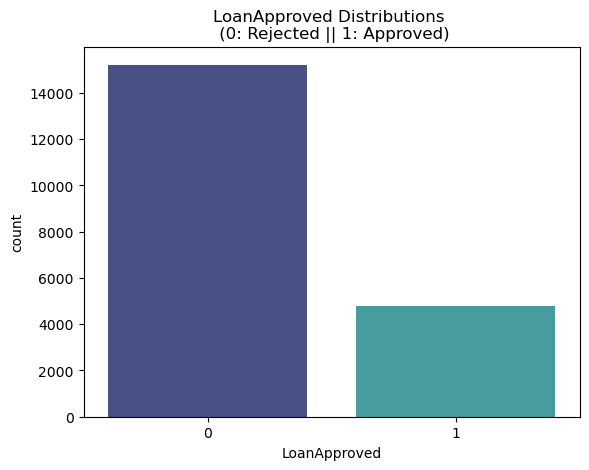

In [ ]:
sns.countplot(data=df, x="LoanApproved", palette='mako')
plt.title('LoanApproved Distributions \n (0: Rejected || 1: Approved)')
plt.show()


We'll create a dataset such that the number of samples of loans approved and rejected are the same.

We see that the original dataset is highly imbalanced hence, will lead to biased results. \
If we continue to use the same dataset, we will face issues like Overfitting on training our machine learning models.

We have 4780 Rejected Loan Applications in the total dataset, out of which, 2865 are in X_train. \
Since we have 2865 Rejected Loan applications in X_train, we need to randomly pick 2865 Approved Loan applications. \
We also need to encode non numerical columns and normalize the dataset.

In [20]:
# Encoding
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

# Let's say these are your categorical columns
categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

encoder.fit(X_train[categorical_cols])
X_train[categorical_cols] = encoder.transform(X_train[categorical_cols])
X_val[categorical_cols] = encoder.transform(X_val[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

In [22]:
for col, categories in zip(categorical_cols, encoder.categories_):
    print(f"Mapping for '{col}':")
    for i, cat in enumerate(categories):
        print(f"  {cat} --> {i}")
    print()

Mapping for 'EmploymentStatus':
  Employed --> 0
  Self-Employed --> 1
  Unemployed --> 2

Mapping for 'EducationLevel':
  Associate --> 0
  Bachelor --> 1
  Doctorate --> 2
  High School --> 3
  Master --> 4

Mapping for 'MaritalStatus':
  Divorced --> 0
  Married --> 1
  Single --> 2
  Widowed --> 3

Mapping for 'HomeOwnershipStatus':
  Mortgage --> 0
  Other --> 1
  Own --> 2
  Rent --> 3

Mapping for 'LoanPurpose':
  Auto --> 0
  Debt Consolidation --> 1
  Education --> 2
  Home --> 3
  Other --> 4



In [21]:
from sklearn.preprocessing import RobustScaler

# RobustScaler is less prone to outliers.
rb_scaler = RobustScaler()

rb_scaler.fit(X_train)
X_train = rb_scaler.transform(X_train)
X_val = rb_scaler.transform(X_val)
X_test = rb_scaler.transform(X_test)

In [72]:
pd.DataFrame(X_train).head()

,Age,CreditScore,EmploymentStatus,EducationLevel,Experience,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,UtilityBillsPaymentHistory,JobTenure,NetWorth,RiskScore,DebtToIncomeRatio,Monthly_LoanToIncomeRatio
17763,57,511,Employed,Master,35,Single,2,Rent,0.363811,2,...,21,25,5801,5246,0.714049,2,34306,51.0,0.183901,0.388267
3364,31,587,Employed,High School,6,Single,4,Mortgage,0.478811,2,...,20,22,5297,722,0.720363,6,95930,50.0,0.082409,0.347455
3134,40,609,Employed,High School,18,Married,4,Mortgage,0.159431,1,...,17,10,7148,784,0.722829,2,36259,53.0,0.071017,0.093312
7992,59,666,Employed,Bachelor,36,Single,0,Mortgage,0.292295,2,...,15,14,2732,7033,0.906780,3,72339,33.6,0.023281,0.029315
2936,32,574,Employed,Doctorate,12,Married,1,Mortgage,0.187842,1,...,27,22,4482,3781,0.703866,4,9862,53.0,0.119505,0.270500


##### Random Under Sampling
We will now remove data to match the number of Loan Approved records

In [22]:
# Let's shuffle the dataset first
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_y_train = pd.concat([X_train,y_train.set_index(X_train.index)], axis = 1)

X_y_train = X_y_train.sample(frac = 1)

# Separately extract Approved and Rejected rows
X_y_approved = X_y_train[X_y_train['LoanApproved'] == 1]
X_y_rejected = X_y_train[X_y_train['LoanApproved'] == 0][:X_y_approved.shape[0]]

X_y_concat = pd.concat([X_y_approved, X_y_rejected], axis = 0)
X_train = X_y_concat.drop(columns=['LoanApproved'])
y_train = X_y_concat['LoanApproved']

In [60]:
X_y_train.shape


(12000, 25)

Let's visualize the Loan distribution now

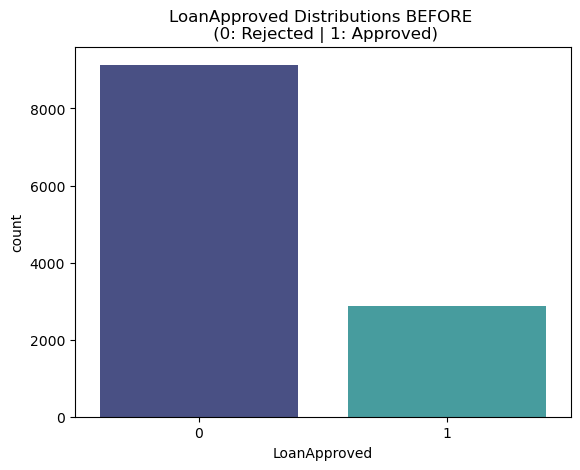

In [63]:
sns.countplot(data=X_y_train, x="LoanApproved", palette='mako')
plt.title('LoanApproved Distributions BEFORE \n (0: Rejected | 1: Approved)')
plt.show()

In [69]:
print("BEFORE")
print(f"Loan Requests Approved: {X_y_train[X_y_train['LoanApproved']==1].shape[0]}/{X_y_train.shape[0]}  =  {X_y_train[X_y_train['LoanApproved']==1].shape[0] / X_y_train.shape[0] * 100}%")
print(f"Loan Requests Rejected: {X_y_train[X_y_train['LoanApproved']==0].shape[0]}/{X_y_train.shape[0]}  =  {X_y_train[X_y_train['LoanApproved']==0].shape[0] / X_y_train.shape[0] * 100}%")

BEFORE
Loan Requests Approved: 2865/12000  =  23.875%
Loan Requests Rejected: 9135/12000  =  76.125%


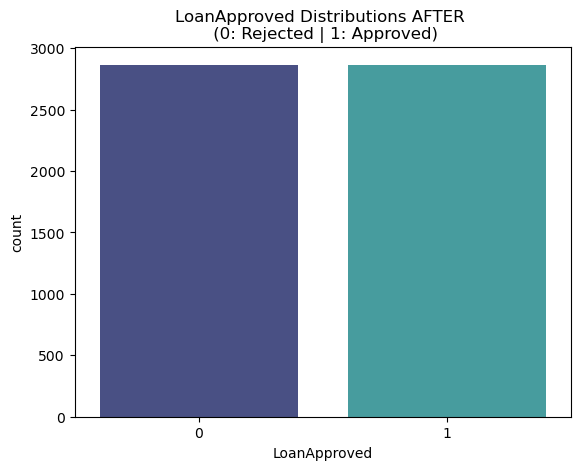

In [64]:
sns.countplot(data=X_y_concat, x="LoanApproved", palette='mako')
plt.title('LoanApproved Distributions AFTER \n (0: Rejected | 1: Approved)')
plt.show()

In [70]:
print("AFTER")
print(f"Loan Requests Approved: {X_y_concat[X_y_concat['LoanApproved']==1].shape[0]}/{X_y_concat.shape[0]}  =  {X_y_concat[X_y_concat['LoanApproved']==1].shape[0] / X_y_concat.shape[0] * 100}%")
print(f"Loan Requests Rejected: {X_y_concat[X_y_concat['LoanApproved']==0].shape[0]}/{X_y_concat.shape[0]}  =  {X_y_concat[X_y_concat['LoanApproved']==0].shape[0] / X_y_concat.shape[0] * 100}%")

AFTER
Loan Requests Approved: 2865/5730  =  50.0%
Loan Requests Rejected: 2865/5730  =  50.0%


##### Model Training

In [ ]:
# # Train test split
# X = df_subset.drop(columns='LoanApproved', axis = 1)
# y = df_subset['LoanApproved']

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Xtrain, Xtemp, ytrain, ytemp = train_test_split(X, y, test_size= 0.3, stratify=y)
# Xval, Xtest, yval, ytest = train_test_split(Xtemp, ytemp, test_size= 0.5, stratify=ytemp)

# encoder = StandardScaler()

# encoder.fit(Xtrain)
# Xtrain = encoder.transform(Xtrain)
# Xval = encoder.transform(Xval)
# Xtest = encoder.transform(Xtest)

In [27]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_val_pred = lr.predict(X_val)

# Generate a classification report
cr = classification_report(y_val,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4870
           1       0.94      0.98      0.96      1530

    accuracy                           0.98      6400
   macro avg       0.97      0.98      0.97      6400
weighted avg       0.98      0.98      0.98      6400



c:\Users\revan\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [48]:
ypred = lr.predict(Xtest)

# Generate a classification report
cr = classification_report(ytest,ypred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2283
           1       0.99      0.99      0.99       717

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [49]:
import pickle

# save
with open('model.pkl','wb') as f:
    pickle.dump(lr,f)